In [50]:
# In Colab, prefer %pip over !pip
%pip -q uninstall -y tensorflow-decision-forests tensorflow-text tf-keras
import tensorflow as tf; print(tf.__version__)  # should still be 2.18.1


2.19.0


In [51]:
# --- Install deps (Colab) ---
# !pip -q install numpy pandas scikit-learn statsmodels matplotlib tensorflow==2.15.0 openai>=1.37.0

import os, json, math, random, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import acf as sm_acf
import matplotlib.pyplot as plt

# --- Config ---
DATA_PATH = "wind_data_daily.csv"
DATE_COL  = "DATE"
# peek columns to define FEATS dynamically (all non-date columns)
_df_preview = pd.read_csv(DATA_PATH)
FEATS  = [c for c in _df_preview.columns if c != DATE_COL]
TARGET = "WIND"
assert TARGET in FEATS, f"Target {TARGET} not found in dataset columns"
N = 15               # history window (days)
H = 5                # max rollout horizon (days)
SEED = 42             # reproducibility

np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)


In [52]:
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])

# base feature columns (all non-date original columns)
base_feats = [c for c in df.columns if c != DATE_COL]
assert all(c in df.columns for c in base_feats), f"Missing columns from df: {base_feats}"

# sort + clean
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df.dropna(subset=base_feats).reset_index(drop=True)

# cyclic calendar encodings (daily data)
dow = df[DATE_COL].dt.dayofweek.to_numpy()
doy = df[DATE_COL].dt.dayofyear.to_numpy()
df["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365.0)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.0)

# final feature list includes engineered cyclic terms
FEATS = base_feats + ["dow_sin", "dow_cos", "doy_sin", "doy_cos"]
assert TARGET in FEATS, f"Target {TARGET} not found in feature list"

# cast
df[FEATS] = df[FEATS].astype("float32")

print("Using features:", FEATS)
print(df[[DATE_COL] + FEATS].head())


Using features: ['WIND', 'IND', 'RAIN', 'IND.1', 'T.MAX', 'IND.2', 'T.MIN', 'T.MIN.G', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']
        DATE   WIND  IND  RAIN  IND.1  T.MAX  IND.2  T.MIN  T.MIN.G   dow_sin  \
0 1961-01-01  13.67  0.0   0.2    0.0    9.5    0.0    3.7     -1.0 -0.781832   
1 1961-01-02  11.50  0.0   5.1    0.0    7.2    0.0    4.2      1.1  0.000000   
2 1961-01-03  11.25  0.0   0.4    0.0    5.5    0.0    0.5     -0.5  0.781832   
3 1961-01-04   8.63  0.0   0.2    0.0    5.6    0.0    0.4     -3.2  0.974928   
4 1961-01-05  11.92  0.0  10.4    0.0    7.2    1.0   -1.5     -7.5  0.433884   

    dow_cos   doy_sin   doy_cos  
0  0.623490  0.017213  0.999852  
1  1.000000  0.034422  0.999407  
2  0.623490  0.051620  0.998667  
3 -0.222521  0.068802  0.997630  
4 -0.900969  0.085965  0.996298  


In [53]:
values = df[FEATS].values.astype("float32")  # shape (M, F)
scaler = StandardScaler()
values_scaled = scaler.fit_transform(values)

def make_windows(X, N):
    Xw, Yw = [], []
    for i in range(len(X) - N):
        Xw.append(X[i:i+N])     # (N, F)
        Yw.append(X[i+N])       # (F,)
    return np.array(Xw, dtype="float32"), np.array(Yw, dtype="float32")

X_all, y_all = make_windows(values_scaled, N)   # X_all: (T, N, F)  y_all: (T, F)
T = len(X_all)

# chronological split (70/15/15)
tr = int(T * 0.70)
va = int(T * 0.15)

X_train, y_train = X_all[:tr],        y_all[:tr]
X_val,   y_val   = X_all[tr:tr+va],   y_all[tr:tr+va]
X_test,  y_test  = X_all[tr+va:],     y_all[tr+va:]

F_DIM = X_train.shape[-1]
TARGET_IDX = FEATS.index(TARGET)
print("Shapes:", X_train.shape, X_val.shape, X_test.shape, "F_DIM:", F_DIM)


Shapes: (3936, 15, 12) (843, 15, 12) (844, 15, 12) F_DIM: 12


In [54]:
def inv_transform(arr):
    arr = np.array(arr, dtype="float32")
    if arr.ndim == 1: arr = arr.reshape(1, -1)
    return scaler.inverse_transform(arr)

def wind_from_scaled(arr_scaled):
    arr = inv_transform(arr_scaled)  # (H,F)
    return arr[:, TARGET_IDX].ravel()

def rollout_forecast_any(model, start_window, H):
    """Multi-output rollout: (N,F)->(F) step, autoregressive for H steps."""
    st = start_window[np.newaxis, ...].astype("float32")  # (1,N,F)
    outs = []
    for _ in range(H):
        yhat = model.predict(st, verbose=0)[0]            # (F,)
        outs.append(yhat)
        st = np.concatenate([st[:,1:,:], yhat[np.newaxis, np.newaxis, :]], axis=1)
    return np.array(outs, dtype="float32")  # (H,F)

# Metrics
def MAE(a,b): return float(np.mean(np.abs(np.asarray(a)-np.asarray(b))))
def RMSE(a,b): return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))
def R2(a,b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    ss_res = np.sum((a-b)**2)
    ss_tot = np.sum((a - np.mean(a))**2) + 1e-9
    return float(1.0 - ss_res/ss_tot)
def sharpness_std(x):
    x = np.asarray(x, float);
    return float(np.std(np.diff(x))) if len(x)>1 else 0.0

def acf_vector(x, nlags=48):
    x = np.asarray(x, float)
    nl = int(min(nlags, max(1, len(x)-1)))
    a = sm_acf(x, nlags=nl, fft=False)
    return a[1:].tolist() if len(a)>1 else []

def cos_sim(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    denom = (np.linalg.norm(a)*np.linalg.norm(b) + 1e-8)
    return float(np.dot(a,b)/denom)

def rare_event_mask(real, q=0.9):
    thr = np.quantile(real, q)
    return (real >= thr)

def masked_mae(real, pred, mask):
    real = np.asarray(real); pred = np.asarray(pred); mask = np.asarray(mask).astype(bool)
    if mask.sum()==0: return float("nan")
    return float(np.mean(np.abs(real[mask]-pred[mask])))


In [55]:
W = tf.constant([1.0 if i==TARGET_IDX else 0.3 for i in range(F_DIM)], dtype=tf.float32)
def mse_weighted(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred) * W)

def build_lstm_multivar(units=64, dropout=0.1, lr=1e-3):
    m = models.Sequential([
        layers.Input(shape=(N, F_DIM)),
        layers.LSTM(units, activation="tanh"),
        layers.Dropout(dropout),
        layers.Dense(F_DIM)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=mse_weighted, metrics=["mse","mae"])
    return m

baseline = build_lstm_multivar(64, 0.1, 1e-3)
es = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")
hist_base = baseline.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=200, batch_size=64, verbose=1, callbacks=[es])


Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2993 - mae: 0.6305 - mse: 0.8179 - val_loss: 0.1960 - val_mae: 0.4810 - val_mse: 0.5334
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.2203 - mae: 0.4789 - mse: 0.5848 - val_loss: 0.1695 - val_mae: 0.4258 - val_mse: 0.4510
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1929 - mae: 0.4192 - mse: 0.5033 - val_loss: 0.1502 - val_mae: 0.3587 - val_mse: 0.3917
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1798 - mae: 0.3781 - mse: 0.4651 - val_loss: 0.1449 - val_mae: 0.3471 - val_mse: 0.3797
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.1753 - mae: 0.3692 - mse: 0.4561 - val_loss: 0.1421 - val_mae: 0.3432 - val_mse: 0.3734
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1716 - mae: 0.3639 - mse: 0.4467 - val_loss: 0.1400 - val_mae: 0.3384 - val_mse: 0.3686
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1700 - mae: 0.3601 - mse: 0.4431 - val

In [56]:
# Save pre-GAN baseline weights
BASELINE_SNAPSHOT_WEIGHTS = baseline.get_weights().copy()


In [57]:
# ============================================
# Optimized SINGLE-STEP Conditional GAN (forecaster starts from baseline weights)
# Reuses: scaler, FEATS, TARGET, N, H, X_train, y_train, X_val, y_val, baseline, rollout_forecast_any
# ============================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error

# -----------------------
# Config for GAN section
# -----------------------
IS_MULTIVAR      = True          # F predicts all F_DIM features
BATCH            = 64
EPOCHS_WARMUP    = 5             # slightly longer anchor
EPOCHS_ADV       = 25
LAMBDA_GAN       = 0.2           # higher GAN influence
SEED             = 42
REAL_LABEL       = 0.9           # label smoothing for stability
FAKE_LABEL       = 0.0
LR_F             = 5e-4
LR_D             = 5e-4
GRAD_CLIP        = 1.0

tf.random.set_seed(SEED)
np.random.seed(SEED)

F_DIM      = int(X_train.shape[-1])
TARGET_IDX = FEATS.index(TARGET)

# -------------------------
# Forecaster F = same architecture as baseline, loaded with snapshot weights (to avoid shape mismatch)
# -------------------------
F = build_lstm_multivar(units=64, dropout=0.1, lr=LR_F)
F.set_weights(BASELINE_SNAPSHOT_WEIGHTS)

# ---------------
# Datasets (next-step)
# ---------------
# Inputs: X_train (B,N,F) scaled
# Real next-step wind (scaled): y_train[:, TARGET_IDX:TARGET_IDX+1]
y_train_w = y_train[:, TARGET_IDX:TARGET_IDX+1].astype("float32")
y_val_w   = y_val[:,   TARGET_IDX:TARGET_IDX+1].astype("float32")

ds_tr = tf.data.Dataset.from_tensor_slices((X_train.astype("float32"), y_train_w))                        .shuffle(4096, seed=SEED).batch(BATCH).prefetch(1)
ds_va = tf.data.Dataset.from_tensor_slices((X_val.astype("float32"),   y_val_w))                        .batch(BATCH).prefetch(1)

# -----------------------
# Discriminator (single-step, conditional on past)
# D_step sees: summary(past window) || next_step_wind_scaled
# -----------------------
def build_D_step(units=128, lr=LR_D):
    x_in = layers.Input(shape=(N, F_DIM), name="past_window_scaled")
    y_next = layers.Input(shape=(1,), name="next_wind_scaled")  # WIND (scaled) only

    # summarize past
    h = layers.Bidirectional(layers.LSTM(units))(x_in)
    h = layers.Dense(128, activation="relu")(h)
    h = layers.Dropout(0.3)(h)
    # condition with proposed next wind
    z = layers.Concatenate()([h, y_next])
    z = layers.Dense(128, activation="relu")(z)
    z = layers.Dropout(0.3)(z)
    out = layers.Dense(1, activation="sigmoid")(z)

    m = models.Model([x_in, y_next], out, name="D_step")
    m.compile(optimizer=tf.keras.optimizers.Adam(lr, clipnorm=GRAD_CLIP), loss="binary_crossentropy")
    return m

D_step = build_D_step(128, LR_D)

# -----------------------
# Losses & optimizers
# -----------------------
mse = tf.keras.losses.MeanSquaredError()
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
optF = tf.keras.optimizers.Adam(LR_F, clipnorm=GRAD_CLIP)
optD = tf.keras.optimizers.Adam(LR_D, clipnorm=GRAD_CLIP)

# -------------------------
# Warm-up (brief, next-step) to stabilize F before adversarial phase
# -------------------------
for epoch in range(EPOCHS_WARMUP):
    losses = []
    for xb, yb_w in ds_tr:
        with tf.GradientTape() as tapeF:
            yhat_full = F(xb, training=True)                        # (B,F_DIM) scaled
            yhat_w = yhat_full[:, TARGET_IDX:TARGET_IDX+1]          # (B,1)
            lossF = mse(yb_w, yhat_w)                               # wind-only anchor
        gradsF = tapeF.gradient(lossF, F.trainable_variables)
        optF.apply_gradients(zip(gradsF, F.trainable_variables))
        losses.append(float(lossF.numpy()))
    print(f"[Warmup] Epoch {epoch+1}/{EPOCHS_WARMUP} ? next-step MSE(wind): {np.mean(losses):.4f}")

# -----------------------
# Validation MAE (wind, original units)
# -----------------------
mu = scaler.mean_.astype("float32")
sc = scaler.scale_.astype("float32")
def eval_val_mae():
    y_pred_full = F(X_val, training=False).numpy()
    y_true_full = y_val
    y_pred_w = y_pred_full[:, TARGET_IDX]
    y_true_w = y_true_full[:, TARGET_IDX]
    y_pred_inv = y_pred_w * sc[TARGET_IDX] + mu[TARGET_IDX]
    y_true_inv = y_true_w * sc[TARGET_IDX] + mu[TARGET_IDX]
    return mean_absolute_error(y_true_inv, y_pred_inv)

# -----------------------
# Adversarial training (single-step)
# -----------------------
best_val   = np.inf
patience   = 5
no_improve = 0

@tf.function
def train_D_step(xb, yb_w):
    # real label=1, fake label=0 with smoothing
    with tf.GradientTape() as tapeD:
        real_logits = D_step([xb, yb_w], training=True)
        yhat_full = F(xb, training=False)                            # stop-grad into F for D update
        yhat_w = yhat_full[:, TARGET_IDX:TARGET_IDX+1]
        fake_logits = D_step([xb, yhat_w], training=True)

        loss_real = bce(tf.ones_like(real_logits) * REAL_LABEL, real_logits)
        loss_fake = bce(tf.zeros_like(fake_logits) + FAKE_LABEL, fake_logits)
        lossD = loss_real + loss_fake
    gradsD = tapeD.gradient(lossD, D_step.trainable_variables)
    optD.apply_gradients(zip(gradsD, D_step.trainable_variables))
    return lossD

@tf.function
def train_F_step(xb, yb_w):
    with tf.GradientTape() as tapeF:
        yhat_full = F(xb, training=True)                             # (B,F_DIM)
        yhat_w = yhat_full[:, TARGET_IDX:TARGET_IDX+1]               # (B,1)
        # supervised (next-step wind)
        loss_mse = mse(yb_w, yhat_w)
        # adversarial: make D_step think it's real
        logits = D_step([xb, yhat_w], training=False)
        loss_gan = bce(tf.ones_like(logits) * REAL_LABEL, logits)
        loss_total = loss_mse + LAMBDA_GAN * loss_gan
    gradsF = tapeF.gradient(loss_total, F.trainable_variables)
    optF.apply_gradients(zip(gradsF, F.trainable_variables))
    return loss_mse, loss_gan, loss_total

for epoch in range(1, EPOCHS_ADV + 1):
    lossesD, lossesF_mse, lossesF_gan = [], [], []
    for xb, yb_w in ds_tr:
        ld = train_D_step(xb, yb_w)
        lm, lg, _ = train_F_step(xb, yb_w)
        lossesD.append(float(ld.numpy()))
        lossesF_mse.append(float(lm.numpy()))
        lossesF_gan.append(float(lg.numpy()))
    val_mae = eval_val_mae()
    print(f"[Adv-1step] Epoch {epoch:02d}/{EPOCHS_ADV} ? "
          f"D: {np.mean(lossesD):.4f} | F_mse: {np.mean(lossesF_mse):.4f} | F_gan: {np.mean(lossesF_gan):.4f} | Val MAE: {val_mae:.4f}")

    if val_mae + 1e-6 < best_val:
        best_val = val_mae
        no_improve = 0
        F_best_weights = F.get_weights()
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping adversarial phase.")
            break

# Restore best forecaster weights
if 'F_best_weights' in globals():
    F.set_weights(F_best_weights)

# -----------------------
# Optional: Rollout H steps for a sample start window and plot
# -----------------------
start_win = X_val[-1]  # (N,F) scaled
pred_seq_scaled = rollout_forecast_any(F, start_win, H)             # (H,F) scaled
pred_wind_scaled = pred_seq_scaled[:, TARGET_IDX]
pred_wind = pred_wind_scaled * sc[TARGET_IDX] + mu[TARGET_IDX]

print("Done. Generated H-step forecast sequence (not used during training).")


[Warmup] Epoch 1/5 ? next-step MSE(wind): 0.5990
[Warmup] Epoch 2/5 ? next-step MSE(wind): 0.5912
[Warmup] Epoch 3/5 ? next-step MSE(wind): 0.5792
[Warmup] Epoch 4/5 ? next-step MSE(wind): 0.5819
[Warmup] Epoch 5/5 ? next-step MSE(wind): 0.5834
[Adv-1step] Epoch 01/25 ? D: 1.3717 | F_mse: 0.5779 | F_gan: 0.7800 | Val MAE: 2.6766
[Adv-1step] Epoch 02/25 ? D: 1.3501 | F_mse: 0.5723 | F_gan: 0.7910 | Val MAE: 2.6983
[Adv-1step] Epoch 03/25 ? D: 1.3316 | F_mse: 0.5699 | F_gan: 0.8017 | Val MAE: 2.7214
[Adv-1step] Epoch 04/25 ? D: 1.3048 | F_mse: 0.5686 | F_gan: 0.8191 | Val MAE: 2.6970
[Adv-1step] Epoch 05/25 ? D: 1.2751 | F_mse: 0.5589 | F_gan: 0.8496 | Val MAE: 2.6986
[Adv-1step] Epoch 06/25 ? D: 1.2364 | F_mse: 0.5594 | F_gan: 0.8889 | Val MAE: 2.6925
Early stopping adversarial phase.
Done. Generated H-step forecast sequence (not used during training).


In [58]:
# Rebuild a fresh model with the same architecture and load the snapshot
BASELINE_REF = build_lstm_multivar(64, 0.1, 1e-3)
BASELINE_REF.set_weights(BASELINE_SNAPSHOT_WEIGHTS)


In [59]:
def rollout_model_wind(model, start_window, H):
    seq_scaled = rollout_forecast_any(model, start_window, H)
    return wind_from_scaled(seq_scaled)

def horizon_mae(real, pred, k):
    if len(real) < k:
        return float("nan")
    return MAE(real[:k], pred[:k])

def eval_one_window(start_abs_idx):
    total_len   = len(values_scaled)
    start_after = start_abs_idx + N
    H_eff       = max(0, min(H, total_len - start_after))
    if H_eff == 0:
        raise ValueError("Pick an earlier start_abs_idx for a full horizon.")

    start_win   = X_all[start_abs_idx]
    real_scaled = values_scaled[start_after:start_after+H_eff]

    real_w = wind_from_scaled(real_scaled)
    base_w = rollout_model_wind(BASELINE_REF, start_win, H_eff)  # <- snapshot model
    adv_w  = rollout_model_wind(F,            start_win, H_eff)  # <- adversarially tuned

    summary = {
      "baseline": {
        "mae": MAE(real_w, base_w),
        "rmse": RMSE(real_w, base_w),
        "r2": R2(real_w, base_w),
        "rare_event_mae": masked_mae(real_w, base_w, rare_event_mask(real_w, 0.9)),
        "sharpness_std_rollout": sharpness_std(base_w),
        "acf_cosine_sim_to_real": cos_sim(acf_vector(real_w, min(48, H_eff-1)),
                                          acf_vector(base_w, min(48, H_eff-1))),
        "horizon_used": int(H_eff),
        "mae_day1": horizon_mae(real_w, base_w, 1),
        "mae_day2": horizon_mae(real_w, base_w, 2),
        "mae_day3": horizon_mae(real_w, base_w, 3),
        "mae_day4": horizon_mae(real_w, base_w, 4),
        "mae_day5": horizon_mae(real_w, base_w, 5),
        "mae_day6": horizon_mae(real_w, base_w, 6),
        "mae_day7": horizon_mae(real_w, base_w, 7),
        "mae_day8": horizon_mae(real_w, base_w, 8),
        "mae_day9": horizon_mae(real_w, base_w, 9),
        "mae_day10": horizon_mae(real_w, base_w, 10),
      },
      "adv_lstm": {
        "mae": MAE(real_w, adv_w),
        "rmse": RMSE(real_w, adv_w),
        "r2": R2(real_w, adv_w),
        "rare_event_mae": masked_mae(real_w, adv_w, rare_event_mask(real_w, 0.9)),
        "sharpness_std_rollout": sharpness_std(adv_w),
        "acf_cosine_sim_to_real": cos_sim(acf_vector(real_w, min(48, H_eff-1)),
                                          acf_vector(adv_w, min(48, H_eff-1))),
        "horizon_used": int(H_eff),
        "mae_day1": horizon_mae(real_w, adv_w, 1),
        "mae_day2": horizon_mae(real_w, adv_w, 2),
        "mae_day3": horizon_mae(real_w, adv_w, 3),
        "mae_day4": horizon_mae(real_w, adv_w, 4),
        "mae_day5": horizon_mae(real_w, adv_w, 5),
        "mae_day6": horizon_mae(real_w, adv_w, 6),
        "mae_day7": horizon_mae(real_w, adv_w, 7),
        "mae_day8": horizon_mae(real_w, adv_w, 8),
        "mae_day9": horizon_mae(real_w, adv_w, 9),
        "mae_day10": horizon_mae(real_w, adv_w, 10),
      }
    }
    return summary, real_w, base_w, adv_w

start_abs = tr + va
summary, real_w, base_w, adv_w = eval_one_window(start_abs)
import json; print(json.dumps(summary, indent=2))


{
  "baseline": {
    "mae": 2.3571293354034424,
    "rmse": 2.673511505126953,
    "r2": -3.8747734561436458,
    "rare_event_mae": 0.43476104736328125,
    "sharpness_std_rollout": 0.16653128608918527,
    "acf_cosine_sim_to_real": -0.05633417790800185,
    "horizon_used": 5,
    "mae_day1": 0.43476104736328125,
    "mae_day2": 1.2208359241485596,
    "mae_day3": 1.4329031705856323,
    "mae_day4": 1.9726672172546387,
    "mae_day5": 2.3571293354034424,
    "mae_day6": NaN,
    "mae_day7": NaN,
    "mae_day8": NaN,
    "mae_day9": NaN,
    "mae_day10": NaN
  },
  "adv_lstm": {
    "mae": 2.2305898666381836,
    "rmse": 2.6583094596862793,
    "r2": -3.8194939507304735,
    "rare_event_mae": 0.15411901473999023,
    "sharpness_std_rollout": 0.10865897363015119,
    "acf_cosine_sim_to_real": 0.9697849041411118,
    "horizon_used": 5,
    "mae_day1": 0.15411901473999023,
    "mae_day2": 0.866077184677124,
    "mae_day3": 1.1387749910354614,
    "mae_day4": 1.779705286026001,
    "mae_da

/tmp/ipython-input-2882116123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, positions=[h-0.2, h+0.2], widths=0.3, patch_artist=True, labels=[None, None])


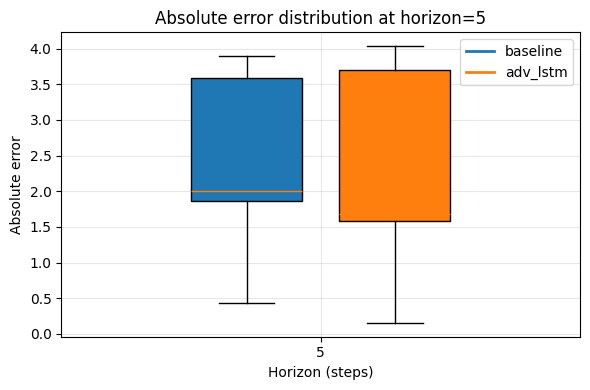

In [60]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# assumes real_w, base_w, adv_w are defined (same horizon/rollout)
h = len(real_w)  # effective horizon
records = []
for model, pred in [("baseline", base_w), ("adv_lstm", adv_w)]:
    errs = np.abs(np.asarray(real_w, float) - np.asarray(pred, float))
    for e in errs:
        records.append({"horizon": h, "model": model, "abs_err": e})

df = pd.DataFrame(records)

models = ["baseline", "adv_lstm"]
colors = {"baseline": "#1f77b4", "adv_lstm": "#ff7f0e"}

plt.figure(figsize=(6,4))
ax = plt.gca()
data = [df[df["model"] == m]["abs_err"].dropna() for m in models]
bp = ax.boxplot(data, positions=[h-0.2, h+0.2], widths=0.3, patch_artist=True, labels=[None, None])
for patch, m in zip(bp["boxes"], models):
    patch.set_facecolor(colors[m])

ax.set_xticks([h])
ax.set_xticklabels([str(h)])
ax.set_xlabel("Horizon (steps)")
ax.set_ylabel("Absolute error")
ax.set_title(f"Absolute error distribution at horizon={h}")
ax.legend(handles=[
    plt.Line2D([0],[0], color=colors["baseline"], lw=2, label="baseline"),
    plt.Line2D([0],[0], color=colors["adv_lstm"], lw=2, label="adv_lstm")
])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
